In [1]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
DATA_DIR = Path("data")
PROCESSED_DIR = DATA_DIR / "processed"

In [3]:
train_path = PROCESSED_DIR / "train_windows_65.pkl"
val_path = PROCESSED_DIR / "val_windows_65.pkl"
test_path = PROCESSED_DIR / "test_windows_65.pkl"

with open(train_path, "rb") as f:
    train_windows = pickle.load(f)

with open(val_path, "rb") as f:
    val_windows = pickle.load(f)

with open(test_path, "rb") as f:
    test_windows = pickle.load(f)

print(len(train_windows), len(val_windows), len(test_windows))

929004 113997 118229


In [4]:
FEATURE_COLUMNS = [
    "resname",
    "polarity_group",
    "hydropathy_group",
    "volume_group",
    "chemical_group",
    "physicochemical_group",
    "charge_group",
    "hydrogen_donor_acceptor_group",
]

WINDOW_SIZE = 65
IGNORE_INDEX = -100

In [5]:
PAD_TOKEN = "PAD"
UNK_TOKEN = "UNK"

cat_to_idx = {}

for col in FEATURE_COLUMNS:
    values = set()

    for sample in train_windows:
        for residue_features in sample["features"]:
            values.add(residue_features[col])

    values = sorted(values)

    vocab = [PAD_TOKEN, UNK_TOKEN]
    for value in values:
        if value not in vocab:
            vocab.append(value)

    cat_to_idx[col] = {value: idx for idx, value in enumerate(vocab)}

In [6]:
for col in FEATURE_COLUMNS:
    print(col, len(cat_to_idx[col]), cat_to_idx[col])

resname 22 {'PAD': 0, 'UNK': 1, 'ALA': 2, 'ARG': 3, 'ASN': 4, 'ASP': 5, 'CYS': 6, 'GLN': 7, 'GLU': 8, 'GLY': 9, 'HIS': 10, 'ILE': 11, 'LEU': 12, 'LYS': 13, 'MET': 14, 'PHE': 15, 'PRO': 16, 'SER': 17, 'THR': 18, 'TRP': 19, 'TYR': 20, 'VAL': 21}
polarity_group 4 {'PAD': 0, 'UNK': 1, 'nonpolar': 2, 'polar': 3}
hydropathy_group 5 {'PAD': 0, 'UNK': 1, 'hydrophilic': 2, 'hydrophobic': 3, 'neutral': 4}
volume_group 6 {'PAD': 0, 'UNK': 1, 'large': 2, 'medium': 3, 'small': 4, 'very_small': 5}
chemical_group 13 {'PAD': 0, 'UNK': 1, 'acidic': 2, 'aliphatic': 3, 'amide': 4, 'aromatic': 5, 'aromatic_hydroxyl': 6, 'basic': 7, 'basic_aromatic': 8, 'cyclic': 9, 'hydroxyl': 10, 'special': 11, 'sulfur': 12}
physicochemical_group 11 {'PAD': 0, 'UNK': 1, 'aromatic': 2, 'aromatic_polar': 3, 'negative': 4, 'nonpolar_aliphatic': 5, 'nonpolar_sulfur': 6, 'polar_uncharged': 7, 'positive': 8, 'positive_weak': 9, 'special': 10}
charge_group 6 {'PAD': 0, 'UNK': 1, 'negative': 2, 'neutral': 3, 'positive': 4, 'posi

In [7]:
class Chi1WindowDataset(Dataset):
    def __init__(self, samples, feature_columns, cat_to_idx):
        self.samples = samples
        self.feature_columns = feature_columns
        self.cat_to_idx = cat_to_idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        x_cat = []

        for residue_features in sample["features"]:
            row = []

            for col in self.feature_columns:
                value = residue_features[col]

                encoded_value = self.cat_to_idx[col].get(
                    value,
                    self.cat_to_idx[col][UNK_TOKEN],
                )

                row.append(encoded_value)

            x_cat.append(row)

        x_cat = torch.tensor(x_cat, dtype=torch.long)
        y = torch.tensor(sample["targets"], dtype=torch.long)
        target_mask = torch.tensor(sample["target_mask"], dtype=torch.bool)
        padding_mask = torch.tensor(sample["padding_mask"], dtype=torch.bool)

        return {
            "x_cat": x_cat,
            "y": y,
            "target_mask": target_mask,
            "padding_mask": padding_mask,
            "pdb_id": sample["pdb_id"],
            "chain_id": sample["chain_id"],
            "center_residue_number": sample["center_residue_number"],
            "center_resname": sample["center_resname"],
        }

In [8]:
train_dataset = Chi1WindowDataset(
    samples=train_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

val_dataset = Chi1WindowDataset(
    samples=val_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

test_dataset = Chi1WindowDataset(
    samples=test_windows,
    feature_columns=FEATURE_COLUMNS,
    cat_to_idx=cat_to_idx,
)

NameError: name 'Chi1WindowDataset' is not defined

In [7]:
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
)

NameError: name 'train_dataset' is not defined

In [ ]:
batch = next(iter(train_loader))

print(batch["x_cat"].shape)
print(batch["y"].shape)
print(batch["target_mask"].shape)
print(batch["padding_mask"].shape)

torch.Size([128, 65, 8])
torch.Size([128, 65])
torch.Size([128, 65])
torch.Size([128, 65])


In [28]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import random
import numpy as np
from tqdm.auto import tqdm

In [12]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "mps")
device

device(type='mps')

In [13]:
NUM_CLASSES = 36
WINDOW_SIZE = 65
IGNORE_INDEX = -100

PAD_TOKEN = "PAD"
UNK_TOKEN = "UNK"

In [14]:
cat_to_idx = {}

for col in FEATURE_COLUMNS:
    values = set()

    for sample in train_windows:
        for residue_features in sample["features"]:
            values.add(residue_features[col])

    values = sorted(values)

    vocab = [PAD_TOKEN, UNK_TOKEN]

    for value in values:
        if value not in vocab:
            vocab.append(value)

    cat_to_idx[col] = {value: idx for idx, value in enumerate(vocab)}

In [15]:
for col in FEATURE_COLUMNS:
    print(col, len(cat_to_idx[col]))

resname 22
polarity_group 4
hydropathy_group 5
volume_group 6
chemical_group 13
physicochemical_group 11
charge_group 6
hydrogen_donor_acceptor_group 6


In [16]:
class Chi1Transformer(nn.Module):
    def __init__(
        self,
        cat_vocab_sizes,
        cat_embedding_dims,
        d_model=128,
        nhead=8,
        num_layers=4,
        dim_feedforward=256,
        dropout=0.1,
        num_classes=36,
        window_size=65,
    ):
        super().__init__()

        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(
                num_embeddings=vocab_size,
                embedding_dim=emb_dim,
                padding_idx=0,
            )
            for vocab_size, emb_dim in zip(cat_vocab_sizes, cat_embedding_dims)
        ])

        total_cat_dim = sum(cat_embedding_dims)

        self.input_projection = nn.Sequential(
            nn.Linear(total_cat_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
        )

        self.position_embedding = nn.Embedding(window_size, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=num_layers,
        )

        self.classifier = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, x_cat, padding_mask=None):
        batch_size, seq_len, num_features = x_cat.shape

        embedded_features = []

        for feature_idx, embedding_layer in enumerate(self.cat_embeddings):
            feature_values = x_cat[:, :, feature_idx]
            feature_emb = embedding_layer(feature_values)
            embedded_features.append(feature_emb)

        x = torch.cat(embedded_features, dim=-1)
        x = self.input_projection(x)

        positions = torch.arange(seq_len, device=x.device)
        positions = positions.unsqueeze(0).expand(batch_size, seq_len)

        x = x + self.position_embedding(positions)

        x = self.encoder(
            x,
            src_key_padding_mask=padding_mask,
        )

        logits = self.classifier(x)

        return logits

In [17]:
cat_vocab_sizes = [len(cat_to_idx[col]) for col in FEATURE_COLUMNS]

cat_embedding_dims = [
    min(32, max(4, vocab_size // 2))
    for vocab_size in cat_vocab_sizes
]

print("Vocab sizes:", cat_vocab_sizes)
print("Embedding dims:", cat_embedding_dims)

Vocab sizes: [22, 4, 5, 6, 13, 11, 6, 6]
Embedding dims: [11, 4, 4, 4, 6, 5, 4, 4]


In [18]:
model = Chi1Transformer(
    cat_vocab_sizes=cat_vocab_sizes,
    cat_embedding_dims=cat_embedding_dims,
    d_model=128,
    nhead=8,
    num_layers=4,
    dim_feedforward=256,
    dropout=0.1,
    num_classes=NUM_CLASSES,
    window_size=WINDOW_SIZE,
).to(device)

/opt/anaconda3/lib/python3.12/site-packages/torch/nn/modules/transformer.py:379: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [19]:
batch = next(iter(train_loader))

x_cat = batch["x_cat"].to(device)
padding_mask = batch["padding_mask"].to(device)

with torch.no_grad():
    logits = model(x_cat, padding_mask=padding_mask)

print(logits.shape)

torch.Size([128, 65, 36])


In [20]:
criterion = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

y = batch["y"].to(device)

loss = criterion(
    logits.reshape(-1, NUM_CLASSES),
    y.reshape(-1),
)

loss

tensor(3.9106, device='mps:0')

In [21]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4,
)

In [22]:
def circular_bin_distance(pred_bins, true_bins, num_bins=36):
    diff = torch.abs(pred_bins - true_bins)
    return torch.minimum(diff, num_bins - diff)

In [23]:
def compute_metrics(logits, y, target_mask):
    pred_bins = torch.argmax(logits, dim=-1)

    valid_mask = target_mask & (y != IGNORE_INDEX)

    if valid_mask.sum() == 0:
        return {
            "acc_exact": 0.0,
            "acc_pm1": 0.0,
            "acc_pm3": 0.0,
            "mean_circular_distance": 0.0,
            "num_valid": 0,
        }

    pred_valid = pred_bins[valid_mask]
    y_valid = y[valid_mask]

    distances = circular_bin_distance(pred_valid, y_valid, num_bins=NUM_CLASSES)

    acc_exact = (distances == 0).float().mean().item()
    acc_pm1 = (distances <= 1).float().mean().item()
    acc_pm3 = (distances <= 3).float().mean().item()
    mean_distance = distances.float().mean().item()

    return {
        "acc_exact": acc_exact,
        "acc_pm1": acc_pm1,
        "acc_pm3": acc_pm3,
        "mean_circular_distance": mean_distance,
        "num_valid": int(valid_mask.sum().item()),
    }

In [29]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for batch in progress_bar:
        x_cat = batch["x_cat"].to(device)
        y = batch["y"].to(device)
        target_mask = batch["target_mask"].to(device)
        padding_mask = batch["padding_mask"].to(device)

        optimizer.zero_grad()

        logits = model(x_cat, padding_mask=padding_mask)

        loss = criterion(
            logits.reshape(-1, NUM_CLASSES),
            y.reshape(-1),
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        with torch.no_grad():
            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    metrics = {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

    return metrics

In [30]:
def evaluate(model, loader, criterion, device, desc="Validation"):
    model.eval()

    total_loss = 0.0
    total_valid = 0

    total_exact_correct = 0
    total_pm1_correct = 0
    total_pm3_correct = 0
    total_distance = 0.0

    progress_bar = tqdm(loader, desc=desc, leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            x_cat = batch["x_cat"].to(device)
            y = batch["y"].to(device)
            target_mask = batch["target_mask"].to(device)
            padding_mask = batch["padding_mask"].to(device)

            logits = model(x_cat, padding_mask=padding_mask)

            loss = criterion(
                logits.reshape(-1, NUM_CLASSES),
                y.reshape(-1),
            )

            pred_bins = torch.argmax(logits, dim=-1)
            valid_mask = target_mask & (y != IGNORE_INDEX)

            if valid_mask.sum() > 0:
                pred_valid = pred_bins[valid_mask]
                y_valid = y[valid_mask]

                distances = circular_bin_distance(
                    pred_valid,
                    y_valid,
                    num_bins=NUM_CLASSES,
                )

                num_valid = int(valid_mask.sum().item())

                total_valid += num_valid
                total_loss += loss.item() * num_valid

                total_exact_correct += int((distances == 0).sum().item())
                total_pm1_correct += int((distances <= 1).sum().item())
                total_pm3_correct += int((distances <= 3).sum().item())
                total_distance += float(distances.float().sum().item())

                progress_bar.set_postfix({
                    "loss": total_loss / total_valid,
                    "acc@±3": total_pm3_correct / total_valid,
                })

    metrics = {
        "loss": total_loss / total_valid,
        "acc_exact": total_exact_correct / total_valid,
        "acc_pm1": total_pm1_correct / total_valid,
        "acc_pm3": total_pm3_correct / total_valid,
        "mean_circular_distance": total_distance / total_valid,
    }

    return metrics

In [26]:
NUM_EPOCHS = 10

history = []

best_val_acc_pm3 = -1.0
best_model_path = PROCESSED_DIR / "best_chi1_transformer.pt"

In [31]:
for epoch in tqdm(range(1, NUM_EPOCHS + 1), desc="Epochs"):
    train_metrics = train_one_epoch(
        model=model,
        loader=train_loader,
        optimizer=optimizer,
        criterion=criterion,
        device=device,
    )

    val_metrics = evaluate(
        model=model,
        loader=val_loader,
        criterion=criterion,
        device=device,
        desc="Validation",
    )

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_acc_exact": train_metrics["acc_exact"],
        "train_acc_pm1": train_metrics["acc_pm1"],
        "train_acc_pm3": train_metrics["acc_pm3"],
        "train_mean_circular_distance": train_metrics["mean_circular_distance"],
        "val_loss": val_metrics["loss"],
        "val_acc_exact": val_metrics["acc_exact"],
        "val_acc_pm1": val_metrics["acc_pm1"],
        "val_acc_pm3": val_metrics["acc_pm3"],
        "val_mean_circular_distance": val_metrics["mean_circular_distance"],
    }

    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_metrics['loss']:.4f} | "
        f"train acc@±3 {train_metrics['acc_pm3']:.4f} | "
        f"val loss {val_metrics['loss']:.4f} | "
        f"val acc@±3 {val_metrics['acc_pm3']:.4f} | "
        f"val exact {val_metrics['acc_exact']:.4f}"
    )

    if val_metrics["acc_pm3"] > best_val_acc_pm3:
        best_val_acc_pm3 = val_metrics["acc_pm3"]

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "cat_to_idx": cat_to_idx,
                "feature_columns": FEATURE_COLUMNS,
                "cat_vocab_sizes": cat_vocab_sizes,
                "cat_embedding_dims": cat_embedding_dims,
                "model_config": {
                    "d_model": 128,
                    "nhead": 8,
                    "num_layers": 4,
                    "dim_feedforward": 256,
                    "dropout": 0.1,
                    "num_classes": NUM_CLASSES,
                    "window_size": WINDOW_SIZE,
                },
                "best_val_acc_pm3": best_val_acc_pm3,
                "epoch": epoch,
            },
            best_model_path,
        )

        print(f"Saved best model to {best_model_path}")

Epochs:   0%|          | 0/10 [00:00<?, ?it/s]

Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 01 | train loss 2.5302 | train acc@±3 0.5492 | val loss 2.4513 | val acc@±3 0.5681 | val exact 0.2592
Saved best model to data/processed/best_chi1_transformer.pt


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 09 | train loss 2.3212 | train acc@±3 0.6068 | val loss 2.3069 | val acc@±3 0.6170 | val exact 0.3033
Saved best model to data/processed/best_chi1_transformer.pt


Training:   0%|          | 0/7258 [00:00<?, ?it/s]

Validation:   0%|          | 0/891 [00:00<?, ?it/s]

Epoch 10 | train loss 2.3104 | train acc@±3 0.6088 | val loss 2.3056 | val acc@±3 0.6177 | val exact 0.3036
Saved best model to data/processed/best_chi1_transformer.pt


In [32]:
history_df = pd.DataFrame(history)
history_df

,epoch,train_loss,train_acc_exact,train_acc_pm1,train_acc_pm3,train_mean_circular_distance,val_loss,val_acc_exact,val_acc_pm1,val_acc_pm3,val_mean_circular_distance
0,1,2.530204,0.233721,0.454875,0.549177,5.327578,2.451285,0.259203,0.476679,0.568118,5.106794
1,2,2.479661,0.251147,0.470486,0.563633,5.151866,2.402871,0.277352,0.493865,0.584280,4.908555
2,3,2.437802,0.266724,0.486556,0.578758,4.970245,2.364537,0.288978,0.506335,0.596839,4.758227
3,4,2.409942,0.274590,0.495433,0.587315,4.869073,2.343772,0.294593,0.513343,0.603612,4.682482
4,5,2.386497,0.280205,0.502013,0.593650,4.796963,2.324624,0.298965,0.519517,0.609683,4.613786
5,6,2.365359,0.284782,0.507397,0.598861,4.736523,2.315934,0.301090,0.522290,0.612803,4.573292
6,7,2.348140,0.287679,0.510737,0.602107,4.698634,2.316035,0.302145,0.523913,0.614365,4.559996
7,8,2.333585,0.289840,0.513299,0.604739,4.668333,2.312929,0.302862,0.524997,0.615922,4.540332
8,9,2.321218,0.291509,0.515291,0.606829,4.644135,2.306944,0.303333,0.525850,0.616989,4.525924
9,10,2.310390,0.293153,0.517220,0.608848,4.621060,2.305616,0.303579,0.526268,0.617736,4.514605


In [33]:
history_path = PROCESSED_DIR / "training_history_chi1_transformer.csv"
history_df.to_csv(history_path, index=False)

print("Saved history:", history_path)

Saved history: data/processed/training_history_chi1_transformer.csv


In [34]:
import matplotlib.pyplot as plt

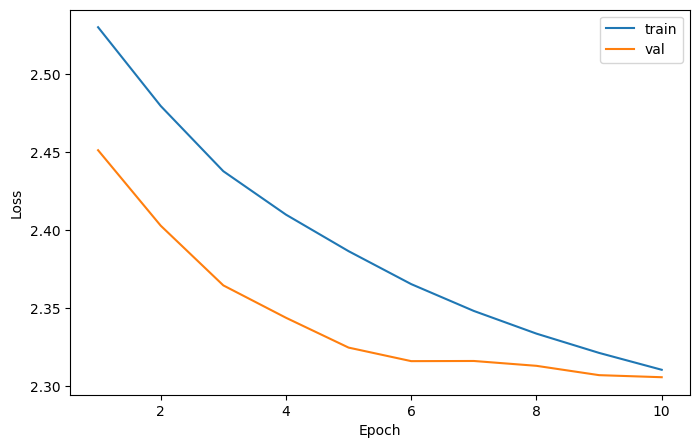

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["val_loss"], label="val")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

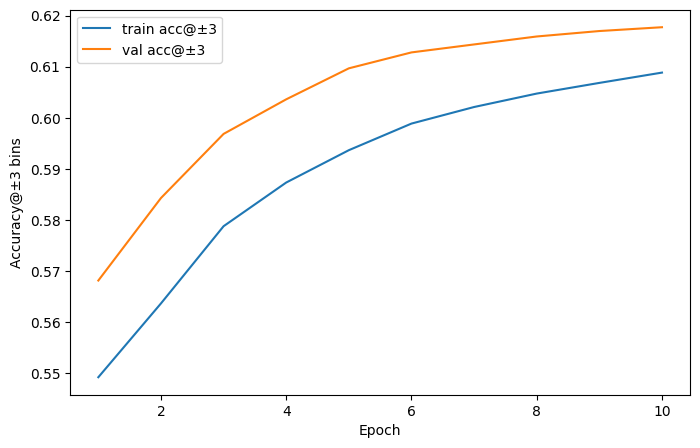

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_acc_pm3"], label="train acc@±3")
plt.plot(history_df["epoch"], history_df["val_acc_pm3"], label="val acc@±3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy@±3 bins")
plt.legend()
plt.show()